<a href="https://colab.research.google.com/github/Vivekthakur24/Python-Basic/blob/main/logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
from sklearn .model_selection import train_test_split
from sklearn .linear_model import LogisticRegression
from sklearn .metrics import accuracy_score,accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder

# Data Loading

In [6]:
data= pd.read_csv("/content/Titanic-Dataset.csv")
data.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [22]:
data.isnull()

,Pclass,Sex,Age,SibSp,Parch,Fare,Survived
0,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False
887,False,False,False,False,False,False,False
888,False,False,False,False,False,False,False
889,False,False,False,False,False,False,False


In [24]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    891 non-null    int64  
 1   Sex       891 non-null    int64  
 2   Age       891 non-null    float64
 3   SibSp     891 non-null    int64  
 4   Parch     891 non-null    int64  
 5   Fare      891 non-null    float64
 6   Survived  891 non-null    int64  
dtypes: float64(2), int64(5)
memory usage: 48.9 KB


In [8]:
data.shape

(891, 12)

# Select features and target

In [11]:
features =[ 'Pclass', 'Sex' , 'Age', 'SibSp', 'Parch','Fare']
data = data[features + ['Survived']]


In [12]:
data

,Pclass,Sex,Age,SibSp,Parch,Fare,Survived
0,3,male,22.0,1,0,7.2500,0
1,1,female,38.0,1,0,71.2833,1
2,3,female,26.0,0,0,7.9250,1
3,1,female,35.0,1,0,53.1000,1
4,3,male,35.0,0,0,8.0500,0
...,...,...,...,...,...,...,...
886,2,male,27.0,0,0,13.0000,0
887,1,female,19.0,0,0,30.0000,1
888,3,female,NaN,1,2,23.4500,0
889,1,male,26.0,0,0,30.0000,1


# Handle Missing Values

In [15]:
data['Age'].fillna(data['Age'].median(), inplace=True)

<ipython-input-15-ca72a6c8cabd>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Age'].fillna(data['Age'].median(), inplace=True)
<ipython-input-15-ca72a6c8cabd>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Age'].fillna(data['Age'].median(), inplace=True)


In [16]:
data

,Pclass,Sex,Age,SibSp,Parch,Fare,Survived
0,3,male,22.0,1,0,7.2500,0
1,1,female,38.0,1,0,71.2833,1
2,3,female,26.0,0,0,7.9250,1
3,1,female,35.0,1,0,53.1000,1
4,3,male,35.0,0,0,8.0500,0
...,...,...,...,...,...,...,...
886,2,male,27.0,0,0,13.0000,0
887,1,female,19.0,0,0,30.0000,1
888,3,female,28.0,1,2,23.4500,0
889,1,male,26.0,0,0,30.0000,1


In [18]:
data.isnull()

,Pclass,Sex,Age,SibSp,Parch,Fare,Survived
0,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False
887,False,False,False,False,False,False,False
888,False,False,False,False,False,False,False
889,False,False,False,False,False,False,False


In [19]:
data.notnull()

,Pclass,Sex,Age,SibSp,Parch,Fare,Survived
0,True,True,True,True,True,True,True
1,True,True,True,True,True,True,True
2,True,True,True,True,True,True,True
3,True,True,True,True,True,True,True
4,True,True,True,True,True,True,True
...,...,...,...,...,...,...,...
886,True,True,True,True,True,True,True
887,True,True,True,True,True,True,True
888,True,True,True,True,True,True,True
889,True,True,True,True,True,True,True


# Convert categorical  column 'Sex' to numeric

In [21]:
le = LabelEncoder()
data['Sex']=le.fit_transform(data['Sex']) # male = 1 and female =0

<ipython-input-21-628739bb2585>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Sex']=le.fit_transform(data['Sex'])


# Split features and target

In [25]:
x=data[features]
y=data['Survived']

In [26]:
x

,Pclass,Sex,Age,SibSp,Parch,Fare
0,3,1,22.0,1,0,7.2500
1,1,0,38.0,1,0,71.2833
2,3,0,26.0,0,0,7.9250
3,1,0,35.0,1,0,53.1000
4,3,1,35.0,0,0,8.0500
...,...,...,...,...,...,...
886,2,1,27.0,0,0,13.0000
887,1,0,19.0,0,0,30.0000
888,3,0,28.0,1,2,23.4500
889,1,1,26.0,0,0,30.0000


In [27]:
y

,Survived
0,0
1,1
2,1
3,1
4,0
...,...
886,0
887,1
888,0
889,1


# Train-Test Split

In [28]:
x_train ,x_test ,y_train ,y_test = train_test_split(x,y,test_size=0.3,random_state=42)

In [29]:
x_train

,Pclass,Sex,Age,SibSp,Parch,Fare
331,1,1,45.5,0,0,28.5000
733,2,1,23.0,0,0,13.0000
382,3,1,32.0,0,0,7.9250
704,3,1,26.0,1,0,7.8542
813,3,0,6.0,4,2,31.2750
...,...,...,...,...,...,...
106,3,0,21.0,0,0,7.6500
270,1,1,28.0,0,0,31.0000
860,3,1,41.0,2,0,14.1083
435,1,0,14.0,1,2,120.0000


In [30]:
x_test

,Pclass,Sex,Age,SibSp,Parch,Fare
709,3,1,28.0,1,1,15.2458
439,2,1,31.0,0,0,10.5000
840,3,1,20.0,0,0,7.9250
720,2,0,6.0,0,1,33.0000
39,3,0,14.0,1,0,11.2417
...,...,...,...,...,...,...
433,3,1,17.0,0,0,7.1250
773,3,1,28.0,0,0,7.2250
25,3,0,38.0,1,5,31.3875
84,2,0,17.0,0,0,10.5000


# Train logistic regression

In [32]:
model = LogisticRegression(max_iter=200)
model.fit(x_train,y_train)


LogisticRegression(max_iter=200)

## Prediction

In [34]:
y_pred = model.predict(x_test)
y_pred

array([0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0,
       0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0,
       0, 1, 1])

In [35]:
print("Accuracy:", accuracy_score(y_test,y_pred))
print("Classification Report:\n",classification_report(y_test,y_pred))

Accuracy: 0.8100558659217877
Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.88      0.84       105
           1       0.80      0.72      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



In [40]:
from sklearn.metrics import accuracy_score, classification_report , confusion_matrix, roc_curve, auc

In [41]:
import matplotlib .pyplot as plt
import seaborn as sns

In [42]:
cm = confusion_matrix(y_test,y_pred)


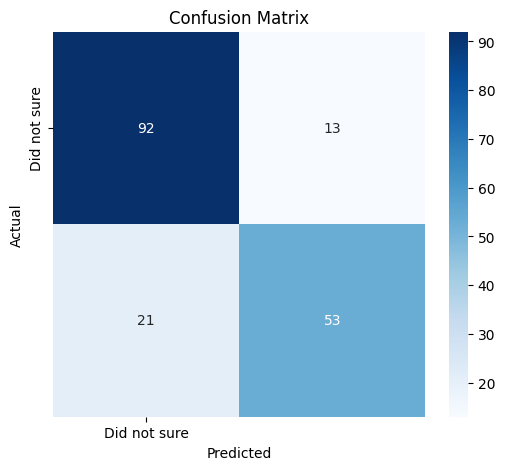

In [47]:
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues' , xticklabels=['Did not sure'],yticklabels=['Did not sure'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()